In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Reading the data
df = pd.read_csv('Dataset_Day13.csv')
df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
#Replacing 0 with NaN for the required columns
cols = ["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm","Species"]
df[cols] = df[cols].replace(0, np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    float64
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(5), object(1)
memory usage: 7.2+ KB


In [10]:
#Treating missing data
numeric_col=[]

for col in df.columns:
    if df[col].dtype.name != 'object':
        numeric_col.append(col)

print(numeric_col)

median_value = df[numeric_col].median()
print(median_value)

df = df.fillna(median_value)
df.info()

['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Id               0.000000
SepalLengthCm   -0.052331
SepalWidthCm    -0.124540
PetalLengthCm    0.335143
PetalWidthCm     0.132781
dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    float64
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(5), object(1)
memory usage: 7.2+ KB


In [19]:
for col in df.drop(["Id", "Species"], axis=1):
    df[col] = (df[col] - df[col].mean()) / df[col].std()

# Outlier Detection using Z-score
OutlierRows = df[
    (df["SepalLengthCm"] > 3) | (df["SepalLengthCm"] < -3) |
    (df["SepalWidthCm"] > 3) | (df["SepalWidthCm"] < -3) |
    (df["PetalLengthCm"] > 3) | (df["PetalLengthCm"] < -3) |
    (df["PetalWidthCm"] > 3) | (df["PetalWidthCm"] < -3)
]

print("% of Outlier rows in the dataset is " + str(len(OutlierRows) / len(df) * 100) + "\n")

# Remove Outliers
data_OutlierFree = df.drop(OutlierRows.index, axis=0)

% of Outlier rows in the dataset is 0.6666666666666667



In [21]:
# Calculate descriptive statistics by species
desc_stats = df.groupby('Species').describe()
print(desc_stats)

                   Id                                                        \
                count          mean       std       min       25%       50%   
Species                                                                       
Iris-setosa      50.0 -1.150871e+00  0.335534 -1.714797 -1.432834 -1.150871   
Iris-versicolor  50.0 -4.440892e-18  0.335534 -0.563927 -0.281963  0.000000   
Iris-virginica   50.0  1.150871e+00  0.335534  0.586944  0.868907  1.150871   

                                    SepalLengthCm            ...  \
                      75%       max         count      mean  ...   
Species                                                      ...   
Iris-setosa     -0.868907 -0.586944          50.0 -1.011191  ...   
Iris-versicolor  0.281963  0.563927          50.0  0.111907  ...   
Iris-virginica   1.432834  1.714797          50.0  0.899284  ...   

                PetalLengthCm           PetalWidthCm                      \
                          75%       max 

In [22]:
X = data_OutlierFree.drop(["Id", "Species"], axis=1)

from sklearn.cluster import KMeans

km = KMeans(n_clusters=4, n_init=7, random_state=1285)
km = km.fit(X)

clusterlabels = km.labels_
clusterWCSS = km.inertia_

In [23]:
clusterlabels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 3, 1, 1, 2, 1, 1, 1, 2, 1, 2, 2, 1, 2, 1, 2, 1, 1,
       2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 1,
       2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 3, 1, 3, 1, 3, 3, 2, 3, 1, 3, 3,
       1, 3, 1, 1, 3, 1, 3, 3, 2, 3, 1, 3, 1, 3, 3, 1, 1, 1, 3, 3, 3, 1,
       1, 1, 3, 3, 1, 1, 3, 3, 3, 1, 3, 3, 3, 1, 1, 3, 1], dtype=int32)

In [24]:
pd.Series(clusterlabels).value_counts().sort_index()

0    48
1    49
2    24
3    28
Name: count, dtype: int64

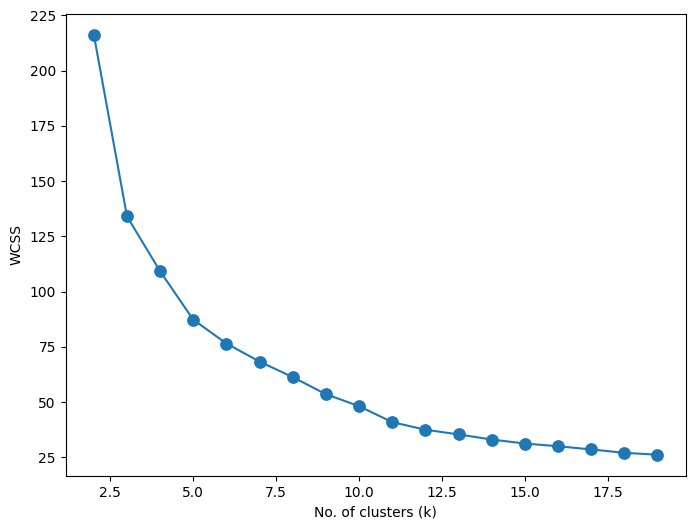

In [25]:
#elbow
wcss = []

for k in range (2,20):
    km = KMeans(n_clusters = k, n_init = 7, random_state = 1285)
    km = km.fit(X)
    wcss.append(km.inertia_)

wcss = pd.Series(wcss, index = range(2,20))

plt.figure(figsize=(8,6))
ax = sns.lineplot(y = wcss, x = wcss.index)
ax = sns.scatterplot(y = wcss, x = wcss.index, s = 100)
ax = ax.set(xlabel = 'No. of clusters (k)', ylabel = 'WCSS')

Observations:-

The graph begins to flatten at around k > 7.
Thus, k > 7 is the ideal balance between model complexity and performance.
Beyond k > 7, WCSS continues to decrease but with diminishing returns.

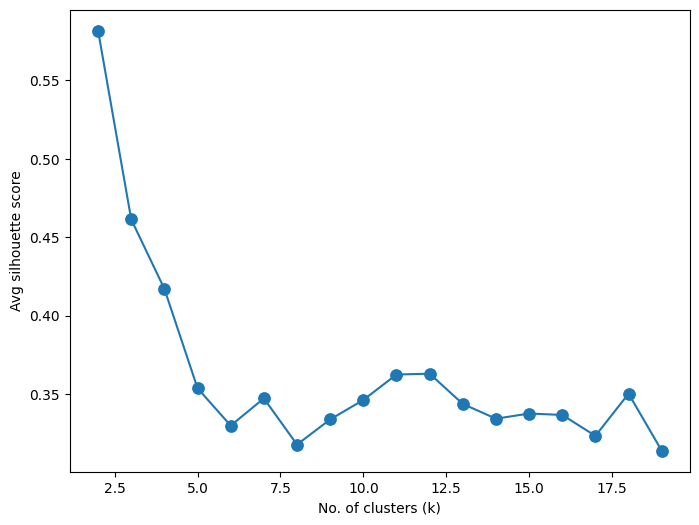

In [26]:
#Silhouette Method:

from sklearn.metrics import silhouette_score

silhouette = []

for k in range (2,20):
    km = KMeans(n_clusters = k, n_init = 7, random_state = 1285)
    km = km.fit(X)
    silhouette.append(silhouette_score(X,km.labels_))

silhouette = pd.Series(silhouette, index = range(2,20))

plt.figure(figsize=(8,6))
ax = sns.lineplot(y = silhouette, x = wcss.index)
ax = sns.scatterplot(y = silhouette, x = wcss.index, s = 100)
ax = ax.set(xlabel = 'No. of clusters (k)', ylabel = 'Avg silhouette score')

Observations:-

Highest average silhoutte score occurs at k = 6.
This means that the most distinct and well-separated clustering occurs when the data is split into 6 clusters.
Beyond this point there may be overlap or poor separation.

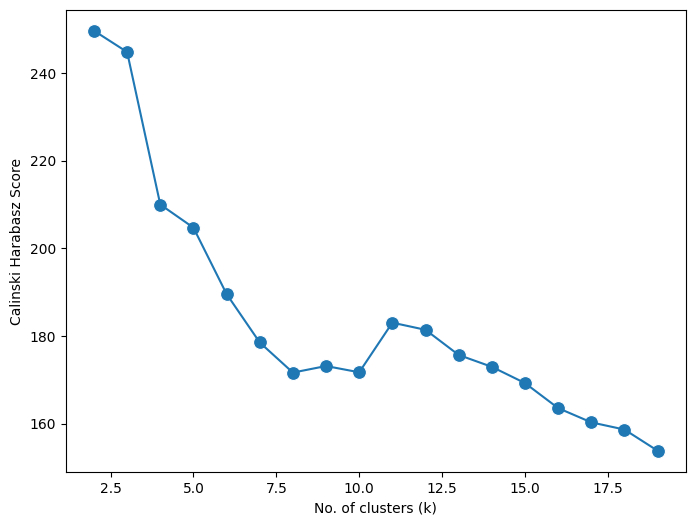

In [27]:
#Calinski Harabasz Score:

# using Calinski Harabasz Score

from sklearn.metrics import calinski_harabasz_score

ch = []

for k in range (2,20):
    km = KMeans(n_clusters = k, n_init = 7, random_state = 1285)
    km = km.fit(X)
    ch.append(calinski_harabasz_score(X,km.labels_))

ch = pd.Series(ch, index = range(2,20))

plt.figure(figsize=(8,6))
ax = sns.lineplot(y = ch, x = ch.index)
ax = sns.scatterplot(y = ch, x = ch.index, s = 100)
ax = ax.set(xlabel = 'No. of clusters (k)', ylabel = 'Calinski Harabasz Score')

Observations:-

This also reaches highest Calinski Harabasz Score at around k = 6.
After this point, we can see there are fluctuations which means k = 6 is the optimal cluster number.

In [33]:
km = KMeans(n_clusters = 6, n_init = 25, random_state = 34)
km.fit(X)

display(pd.Series(km.labels_).value_counts().sort_index())

## 'km.cluster_centers_' :gives the cluster centroids

cluster_centers = pd.DataFrame(km.cluster_centers_, 
                               columns = ['Sepal Length' , 'Sepal Width', 'Petal Length','Petal Width '])
display(cluster_centers)

# to get the correct centroids, we need to un-scale the data,

cluster_centers_unscaled = pd.DataFrame()
for i in ['Sepal Length' , 'Sepal Width', 'Petal Length','Petal Width ']:
    cluster_centers_unscaled[i] = (cluster_centers[i]*df[i].std()) + df[i].mean()

display(cluster_centers_unscaled)


0    29
1    26
2    38
3    21
4    23
5    12
Name: count, dtype: int64

,Sepal Length,Sepal Width,Petal Length,Petal Width
0,0.859640,0.201523,0.852066,1.050019
1,-0.753687,1.383427,-1.293197,-1.212837
2,0.252755,-0.531178,0.546932,0.491400
3,-0.362865,-1.409481,0.107090,0.001747
4,-1.338722,0.126145,-1.309688,-1.302896
5,1.970455,0.163748,1.440322,1.115536


KeyError: 'Sepal Length'

In [34]:
pd.crosstab(data_OutlierFree["Species"], clusterlabels)

col_0,0,1,2,3
Species,,,,
Iris-setosa,48,0,1,0
Iris-versicolor,0,28,21,1
Iris-virginica,0,21,2,27


**Question 6: Share your insights on the data based on the clusters**
**Cluster 0:**

48 samples of Setosa are in cluster 0 with the exception of 1 misclassification, which is a very clean separation.
This confirms our domain knowledge: Setosa is linearly separable.

-----------------------------------------

**Cluster 1:**

Versicolor and Virginica are in cluster 1 in the ratio 28 : 21.
This species overlaps significantly with Virginica, suggesting the need for some more features to overcome the ambiguity.

-----------------------------------------

**Cluster 2:**

Here, the majority is of Versicolor, but it is not a clean separation due to the presence of 1 Setosa and 2 Virginica.
There may have been some edge cases or outliers.

-----------------------------------------

**Cluster 3:**

Here, we have a fairly decent separation as Virginica and Versicolor are in the ratio 27 : 1.
This cluster has better identified Virginica than cluster 2.